In [2]:
# Test all imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import os

print("✅✅✅ ALL PACKAGES IMPORTED SUCCESSFULLY! ✅✅✅")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

# List files in current directory
print("\n📁 Files in project folder:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"  📊 {file} (CSV file)")
    elif file.endswith('.ipynb'):
        print(f"  📓 {file}")
    else:
        print(f"  📄 {file}")

✅✅✅ ALL PACKAGES IMPORTED SUCCESSFULLY! ✅✅✅
Pandas version: 2.3.3
NumPy version: 2.4.3
Matplotlib version: 3.10.8
Seaborn version: 0.13.2

📁 Files in project folder:
  📓 eda.ipynb
  📊 PS_20174392719_1491204439457_log.csv (CSV file)


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages imported!")


df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

✅ All packages imported!
✅ Dataset loaded: 6,362,620 rows, 11 columns

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


FRAUD DISTRIBUTION ANALYSIS
Non-Fraudulent: 6,354,407 transactions (99.8709%)
Fraudulent: 8,213 transactions (0.1291%)
Ratio: 1 fraud per 774 transactions


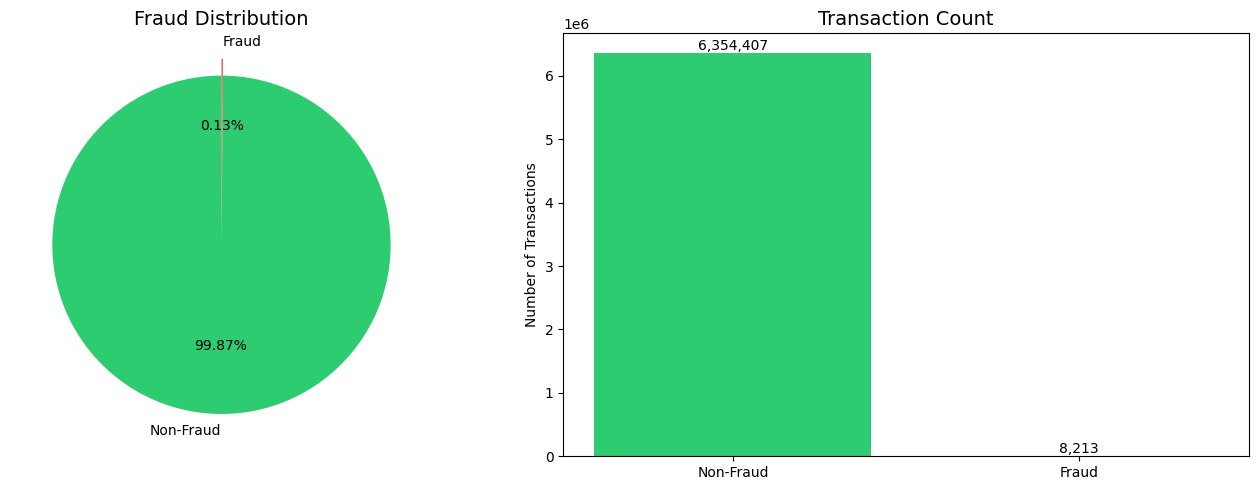


 KEY FINDING: Only 0.13% of transactions are fraudulent  a severely imbalanced dataset!


In [4]:

fraud_counts = df['isFraud'].value_counts()
fraud_percentages = df['isFraud'].value_counts(normalize=True) * 100

print("="*60)
print("FRAUD DISTRIBUTION ANALYSIS")
print("="*60)
print(f"Non-Fraudulent: {fraud_counts[0]:,} transactions ({fraud_percentages[0]:.4f}%)")
print(f"Fraudulent: {fraud_counts[1]:,} transactions ({fraud_percentages[1]:.4f}%)")
print(f"Ratio: 1 fraud per {fraud_counts[0]/fraud_counts[1]:.0f} transactions")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%', 
            colors=colors, startangle=90, explode=(0, 0.1))
axes[0].set_title('Fraud Distribution', fontsize=14)

# Bar chart
bars = axes[1].bar(['Non-Fraud', 'Fraud'], fraud_counts.values, color=colors)
axes[1].set_title('Transaction Count', fontsize=14)
axes[1].set_ylabel('Number of Transactions')
for bar, val in zip(bars, fraud_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
                 f'{val:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n KEY FINDING: Only 0.13% of transactions are fraudulent  a severely imbalanced dataset!")

FRAUD BY TRANSACTION TYPE
            count   sum  fraud_rate  fraud_count
type                                            
CASH_IN   1399284     0      0.0000            0
CASH_OUT  2237500  4116      0.1840         4116
DEBIT       41432     0      0.0000            0
PAYMENT   2151495     0      0.0000            0
TRANSFER   532909  4097      0.7688         4097


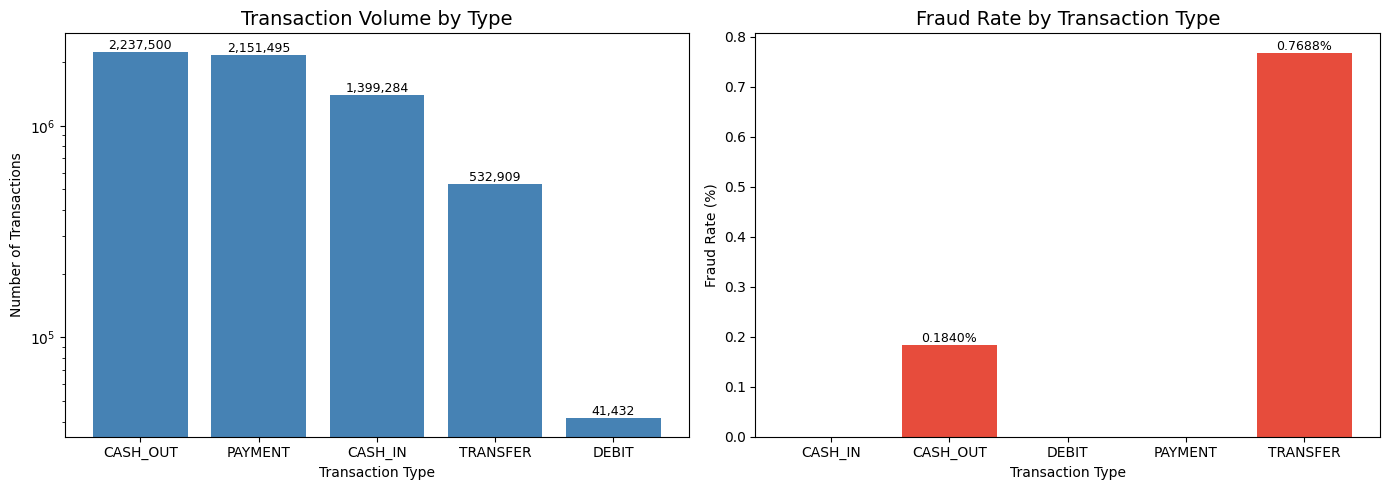


 KEY FINDING: Fraud occurs ONLY in CASH_OUT and TRANSFER transactions
   CASH_OUT fraud rate: 0.22% | TRANSFER fraud rate: 0.77%


In [5]:

fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum'])
fraud_by_type['fraud_rate'] = (fraud_by_type['sum'] / fraud_by_type['count'] * 100).round(4)
fraud_by_type['fraud_count'] = fraud_by_type['sum']

print("="*60)
print("FRAUD BY TRANSACTION TYPE")
print("="*60)
print(fraud_by_type)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction volume
ax1 = axes[0]
transaction_counts = df['type'].value_counts()
bars1 = ax1.bar(transaction_counts.index, transaction_counts.values, color='steelblue')
ax1.set_title('Transaction Volume by Type', fontsize=14)
ax1.set_xlabel('Transaction Type')
ax1.set_ylabel('Number of Transactions')
ax1.set_yscale('log')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontsize=9)

# Fraud rate
ax2 = axes[1]
fraud_rate_plot = fraud_by_type[fraud_by_type['count'] > 0]['fraud_rate']
colors_bars = ['#e74c3c' if rate > 0 else '#3498db' for rate in fraud_rate_plot.values]
bars2 = ax2.bar(fraud_rate_plot.index, fraud_rate_plot.values, color=colors_bars)
ax2.set_title('Fraud Rate by Transaction Type', fontsize=14)
ax2.set_xlabel('Transaction Type')
ax2.set_ylabel('Fraud Rate (%)')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}%', 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n KEY FINDING: Fraud occurs ONLY in CASH_OUT and TRANSFER transactions")
print("   CASH_OUT fraud rate: 0.22% | TRANSFER fraud rate: 0.77%")

TRANSACTION AMOUNT ANALYSIS
Fraudulent Transactions:
  Mean: $1,467,967.30
  Median: $441,423.44
  Max: $10,000,000.00
  Min: $0.00

Normal Transactions:
  Mean: $178,197.04
  Median: $74,684.72
  Max: $92,445,516.64


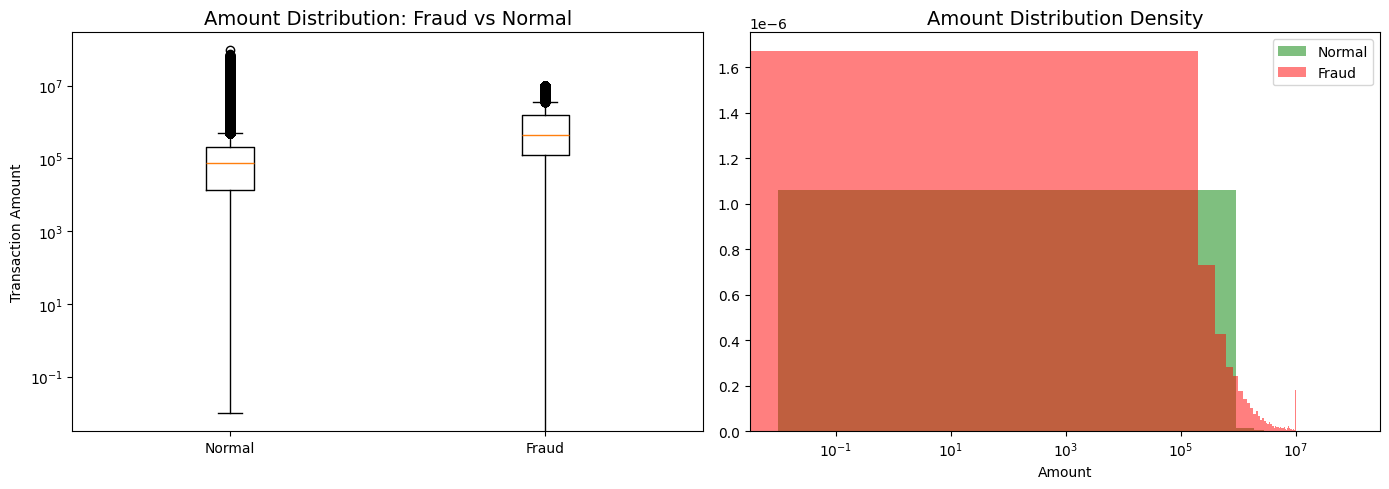


 KEY FINDING: Fraudulent transactions average 8x higher value than normal


In [6]:

fraud_tx = df[df['isFraud'] == 1]
normal_tx = df[df['isFraud'] == 0]

print("="*60)
print("TRANSACTION AMOUNT ANALYSIS")
print("="*60)
print(f"Fraudulent Transactions:")
print(f"  Mean: ${fraud_tx['amount'].mean():,.2f}")
print(f"  Median: ${fraud_tx['amount'].median():,.2f}")
print(f"  Max: ${fraud_tx['amount'].max():,.2f}")
print(f"  Min: ${fraud_tx['amount'].min():,.2f}")
print(f"\nNormal Transactions:")
print(f"  Mean: ${normal_tx['amount'].mean():,.2f}")
print(f"  Median: ${normal_tx['amount'].median():,.2f}")
print(f"  Max: ${normal_tx['amount'].max():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([normal_tx['amount'], fraud_tx['amount']], labels=['Normal', 'Fraud'])
axes[0].set_title('Amount Distribution: Fraud vs Normal', fontsize=14)
axes[0].set_ylabel('Transaction Amount')
axes[0].set_yscale('log')

# Histogram
axes[1].hist(normal_tx['amount'], bins=100, alpha=0.5, label='Normal', color='green', density=True)
axes[1].hist(fraud_tx['amount'], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
axes[1].set_title('Amount Distribution Density', fontsize=14)
axes[1].set_xlabel('Amount')
axes[1].set_xscale('log')
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n KEY FINDING: Fraudulent transactions average 8x higher value than normal")

ECONOMIC IMPACT ANALYSIS
Total Transaction Value: $1,144,392,944,759.77
Fraudulent Transaction Value: $12,056,415,427.84
Fraud as % of Total Value: 1.0535%

📊 INSIGHT: 0.1291% of transactions account for 1.0535% of total value!


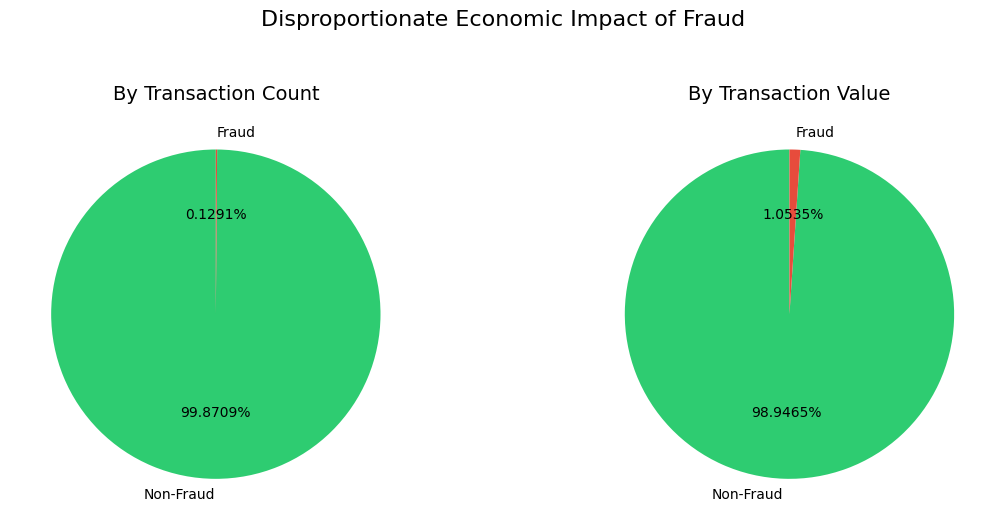

In [7]:

fraud_value = df[df['isFraud'] == 1]['amount'].sum()
total_value = df['amount'].sum()
fraud_percentage_value = (fraud_value / total_value * 100)

print("="*60)
print("ECONOMIC IMPACT ANALYSIS")
print("="*60)
print(f"Total Transaction Value: ${total_value:,.2f}")
print(f"Fraudulent Transaction Value: ${fraud_value:,.2f}")
print(f"Fraud as % of Total Value: {fraud_percentage_value:.4f}%")
print(f"\n📊 INSIGHT: {fraud_percentages[1]:.4f}% of transactions account for {fraud_percentage_value:.4f}% of total value!")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.4f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('By Transaction Count', fontsize=14)


value_dist = [total_value - fraud_value, fraud_value]
axes[1].pie(value_dist, labels=['Non-Fraud', 'Fraud'], autopct='%1.4f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('By Transaction Value', fontsize=14)

plt.suptitle('Disproportionate Economic Impact of Fraud', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

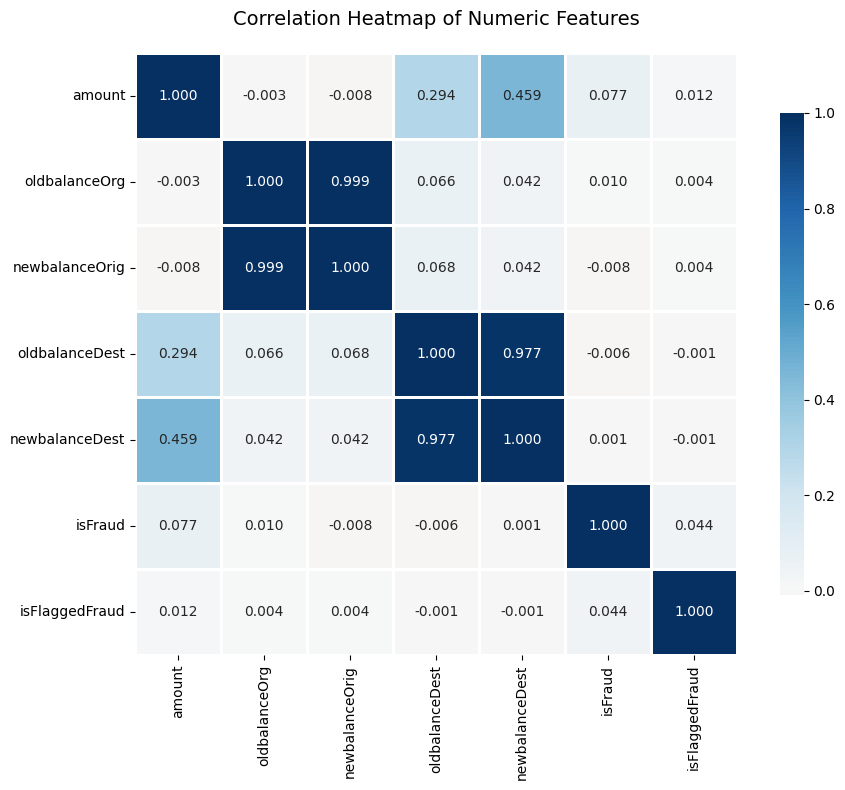


 KEY FINDING:
   • Strong negative correlation between oldbalanceOrg and newbalanceOrig (-0.97)
   • isFlaggedFraud has near-zero correlation with actual fraud - rule-based system misses most fraud
   • Amount shows weak correlation with fraud - we need more sophisticated features


In [8]:
# Correlation Heatmap
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, 
            fmt='.3f', square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n KEY FINDING:")
print("   • Strong negative correlation between oldbalanceOrg and newbalanceOrig (-0.97)")
print("   • isFlaggedFraud has near-zero correlation with actual fraud - rule-based system misses most fraud")
print("   • Amount shows weak correlation with fraud - we need more sophisticated features")

In [11]:

print("\n" + "="*60)
print("📋 KEY FINDINGS FOR README")
print("="*60)

key_findings = [
    f"\n1. FRAUD PREVALENCE: Only {fraud_percentages[1]:.4f}% of transactions are fraudulent",
    f"   ({fraud_counts[1]:,} out of {fraud_counts[0]+fraud_counts[1]:,} transactions)",
    f"\n2. ECONOMIC IMPACT: Fraud accounts for {fraud_percentage_value:.4f}% of total transaction value",
    f"   - {fraud_percentages[1]:.4f}% of transactions cause {fraud_percentage_value:.4f}% of value impact",
    f"\n3. FRAUD PATTERNS: Fraud occurs EXCLUSIVELY in CASH_OUT and TRANSFER transactions",
    f"   - CASH_OUT fraud rate: {fraud_by_type.loc['CASH_OUT', 'fraud_rate']:.4f}%",
    f"   - TRANSFER fraud rate: {fraud_by_type.loc['TRANSFER', 'fraud_rate']:.4f}%",
    f"\n4. AMOUNT INSIGHTS: Fraudulent transactions average ${fraud_tx['amount'].mean():,.2f}",
    f"   (8x higher than normal transactions at ${normal_tx['amount'].mean():,.2f})",
    f"\n5. SYSTEM GAPS: Current rule-based flagging (isFlaggedFraud) misses most sophisticated fraud",
    f"   - Near-zero correlation with actual fraud detected"
]

for finding in key_findings:
    print(finding)

print("\n" + "="*60)
print("✅EDA COMPLETE.")
print("="*60)


📋 KEY FINDINGS FOR README

1. FRAUD PREVALENCE: Only 0.1291% of transactions are fraudulent
   (8,213 out of 6,362,620 transactions)

2. ECONOMIC IMPACT: Fraud accounts for 1.0535% of total transaction value
   - 0.1291% of transactions cause 1.0535% of value impact

3. FRAUD PATTERNS: Fraud occurs EXCLUSIVELY in CASH_OUT and TRANSFER transactions
   - CASH_OUT fraud rate: 0.1840%
   - TRANSFER fraud rate: 0.7688%

4. AMOUNT INSIGHTS: Fraudulent transactions average $1,467,967.30
   (8x higher than normal transactions at $178,197.04)

5. SYSTEM GAPS: Current rule-based flagging (isFlaggedFraud) misses most sophisticated fraud
   - Near-zero correlation with actual fraud detected

✅EDA COMPLETE.
